In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Activation, Dropout, Flatten, MaxPooling2D, BatchNormalization, Conv2D

c:\Users\rauna\anaconda3\envs\anime_venv\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\rauna\anaconda3\envs\anime_venv\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
model = Sequential()
model.add(Input(shape=(227, 227, 3)))

In [3]:
# 1st layer

model.add(Conv2D(filters=96, kernel_size=(11,11), strides=4, padding="valid"))
model.add(Activation("relu"))

model.add(BatchNormalization()) 

model.add(MaxPooling2D(pool_size=(3,3), strides=2, padding="valid"))

In [9]:
# !conda install -y -c conda-forge graphviz

Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\rauna\anaconda3\envs\anime_venv

  added / updated specs:
    - graphviz


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.5.20  |       h4c7d964_0         127 KB  conda-forge
    cairo-1.18.4               |       h477c42c_1         1.5 MB  conda-forge
    certifi-2026.5.20          |     pyhd8ed1ab_0         131 KB  conda-forge
    expat-2.8.1                |       hac47afa_1         130 KB  conda-forge
    flatbuffers-25.9.23        |       h4025804_0         1.7 MB  conda-forge
    font-ttf-dejavu-sans-mono-2.37|       hab24e00_0         388 KB  conda-forge
    font-ttf-inconsolata-3.000 |       h77eed37_0          94 KB  conda-forge
    font-ttf-source-code-pro-2.038|       h77eed37_0         684 KB  conda-forge
   

C:\Users\rauna\anaconda3\Lib\site-packages\conda\base\context.py:969: FutureWarning: Adding 'defaults' to channel list implicitly. is deprecated and will be removed in 25.3. 

To remove this warning, please choose a default channel explicitly via 'conda config --add channels <name>', e.g. 'conda config --add channels defaults'.
  deprecated.topic(


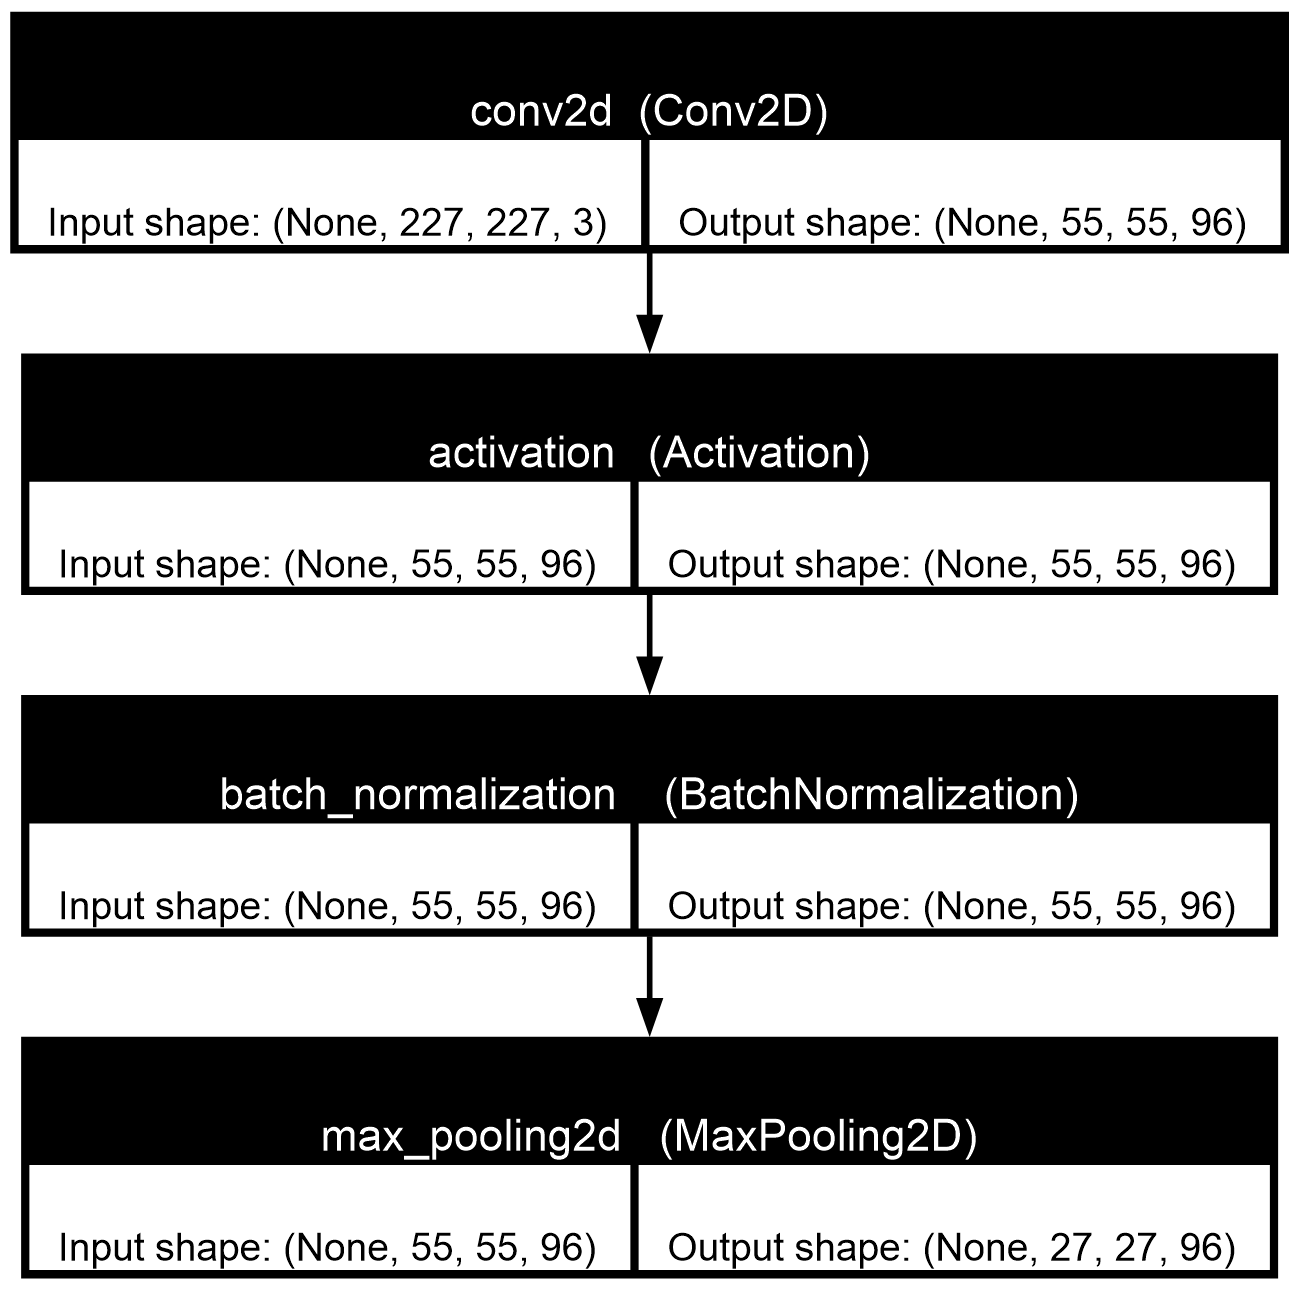

In [ ]:
from tensorflow.keras.utils import plot_model

# This will draw a flow chart inside the notebook
plot_model(model, show_shapes=True, show_layer_names=True)

In [5]:
#2nd convolutional Layer
model.add(Conv2D(filters=256,kernel_size=(5,5),strides=1, padding="same"))
model.add(Activation("relu"))

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(3,3),strides=2))

In [7]:
# 3rd Convolution Layer
model.add(Conv2D(filters=384, kernel_size=(3,3), padding="same",strides =1))
model.add(Activation("relu"))

In [8]:
# 4th Convolution Layer
model.add(Conv2D(filters=384, kernel_size=(3,3),strides=1, padding="same"))
model.add(Activation("relu"))

In [9]:
# 5th Convolution Layer
model.add(Conv2D(filters=256, kernel_size=(3,3),strides=1, padding="same"))
model.add(Activation("relu"))

model.add(MaxPooling2D(pool_size=(3,3), strides=2, padding="same"))


In [10]:
# flattening layer
model.add(Flatten())

In [11]:
# 1st Fully connected layer
model.add(Dense(4096))
model.add(Activation("relu"))
model.add(Dropout(0.5))

In [12]:
# 2nd Fully connected layer
model.add(Dense(4096))
model.add(Activation("relu"))
model.add(Dropout(0.5))

In [13]:
# output Layer
model.add(Dense(1000))
model.add(Activation("softmax"))

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 55, 55, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 55, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 27, 27, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 13, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 13, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    51,384,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     4,097,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 1000)           │             

 Total params: 76,011,240 (289.96 MB)

 Trainable params: 76,010,536 (289.96 MB)

 Non-trainable params: 704 (2.75 KB)

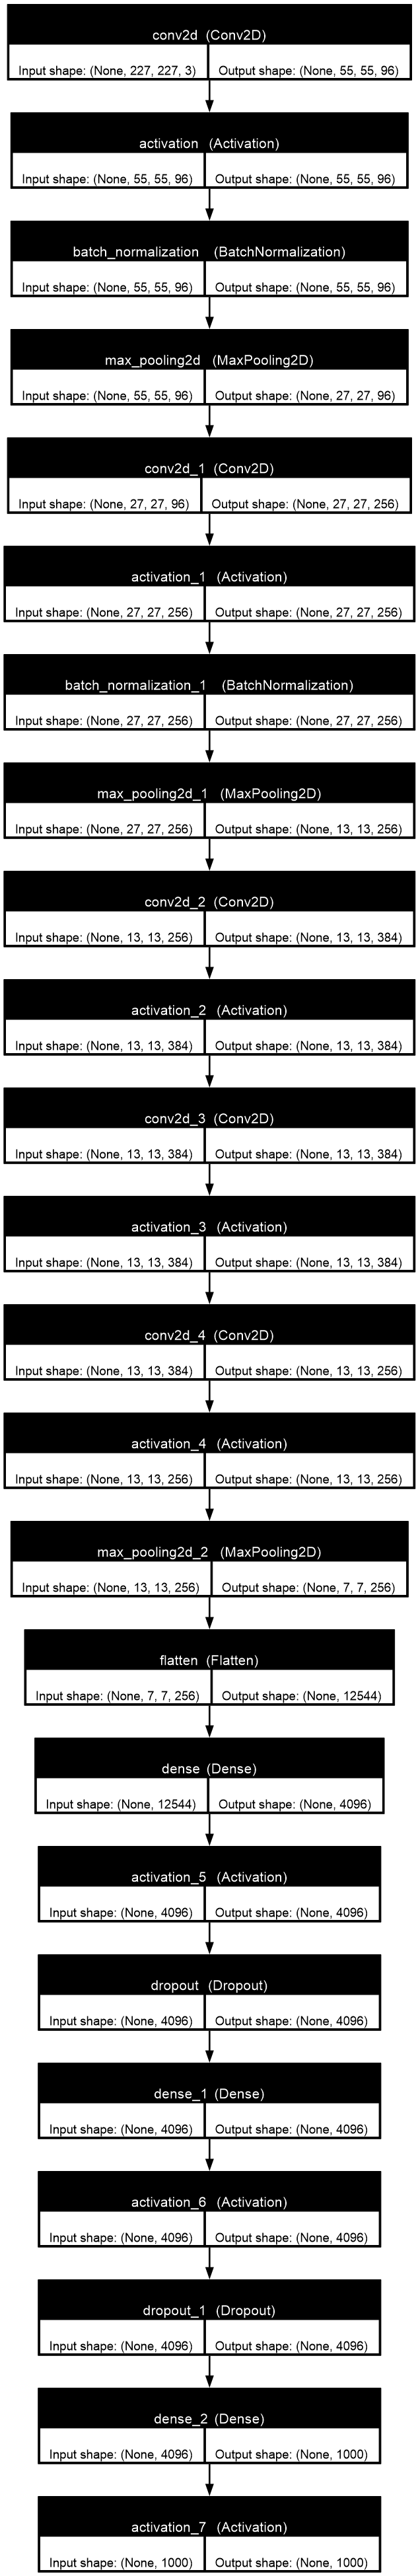

In [19]:
plot_model(model, show_shapes=True, show_layer_names=True, dpi=96)